In [3]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS']= '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import keras as kr
from keras.callbacks import EarlyStopping



In [4]:
set_date_antrenare = kr.utils.image_dataset_from_directory(
    'D:/Licenta/DataSetOrganized/data/train',
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)

set_date_validare = kr.utils.image_dataset_from_directory(
    'D:/Licenta/DataSetOrganized/data/validation',
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)


Found 3200 files belonging to 5 classes.
Found 400 files belonging to 5 classes.


In [5]:
model_data_augumentation = kr.Sequential([kr.layers.RandomFlip("horizontal_and_vertical"),kr.layers.RandomZoom(0.2),kr.layers.RandomRotation(0.2)])

In [6]:
model_antrenare = kr.models.Sequential()

model_antrenare.add(kr.layers.Input(shape=(256,256,3)))
model_antrenare.add(model_data_augumentation)
model_antrenare.add(kr.layers.Rescaling(1./255))

model_antrenare.add(kr.layers.Conv2D(filters=32, kernel_size= 3, padding='same'))
model_antrenare.add(kr.layers.Conv2D(filters=32, kernel_size= 3, padding='same'))
model_antrenare.add(kr.layers.BatchNormalization())
model_antrenare.add(kr.layers.Activation('relu'))
model_antrenare.add(kr.layers.MaxPooling2D(pool_size=2,strides=2))

model_antrenare.add(kr.layers.Conv2D(filters=64, kernel_size= 3, padding='same'))
model_antrenare.add(kr.layers.Conv2D(filters=64,kernel_size= 3, padding='same'))
model_antrenare.add(kr.layers.BatchNormalization())
model_antrenare.add(kr.layers.Activation('relu'))
model_antrenare.add(kr.layers.MaxPooling2D(pool_size=2,strides=2))

model_antrenare.add(kr.layers.Conv2D(filters=128, kernel_size= 3, padding='same'))
model_antrenare.add(kr.layers.Conv2D(filters=128,kernel_size= 3, padding='same'))
model_antrenare.add(kr.layers.BatchNormalization())
model_antrenare.add(kr.layers.Activation('relu'))
model_antrenare.add(kr.layers.MaxPooling2D(pool_size=2,strides=2))

model_antrenare.add(kr.layers.Flatten())

model_antrenare.add(kr.layers.Dense(256, activation='relu',kernel_regularizer=kr.regularizers.l2(0.001)))
model_antrenare.add(kr.layers.Dropout(0.5))

model_antrenare.add(kr.layers.Dense(5, activation='softmax'))

model_antrenare.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005), loss='sparse_categorical_crossentropy',metrics=['accuracy'])

early_stop = kr.callbacks.EarlyStopping(monitor='val_loss', patience=10, verbose=1,restore_best_weights=True)

model_antrenare.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 256, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    33,554,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,843,877 (129.10 MB)

 Trainable params: 33,843,429 (129.10 MB)

 Non-trainable params: 448 (1.75 KB)

In [7]:
model_antrenare_istoric = model_antrenare.fit(x=set_date_antrenare,validation_data = set_date_validare,epochs=20,callbacks=[early_stop])

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 284s 3s/step - accuracy: 0.4534 - loss: 2.2235 - val_accuracy: 0.2000 - val_loss: 2.7720
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 289s 3s/step - accuracy: 0.5103 - loss: 1.6235 - val_accuracy: 0.2000 - val_loss: 4.0843
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 288s 3s/step - accuracy: 0.5278 - loss: 1.5853 - val_accuracy: 0.2000 - val_loss: 4.5397
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 291s 3s/step - accuracy: 0.5494 - loss: 1.4942 - val_accuracy: 0.2125 - val_loss: 3.4298
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 287s 3s/step - accuracy: 0.5500 - loss: 1.4781 - val_accuracy: 0.4625 - val_loss: 1.6495
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 294s 3s/step - accuracy: 0.5631 - loss: 1.4324 - val_accuracy: 0.5925 - val_loss: 1.3589
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 277s 2s/step - accuracy: 0.5606 - loss: 1.4040 - val_accuracy: 0.6400 - val_loss: 1.2759
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 288s 3s/step - accuracy: 0.5838 - loss: 1.3666 - val_accu

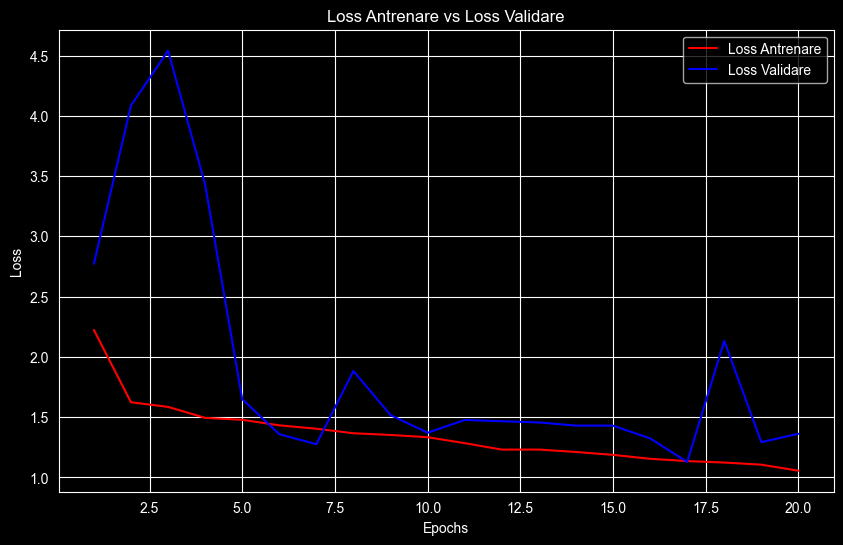

In [8]:
loss = model_antrenare_istoric.history['loss']
val_loss = model_antrenare_istoric.history['val_loss']
epochs = range(1, len(loss) + 1)


plt.figure(figsize = (10,6))
plt.plot(epochs, loss, 'r', label='Loss Antrenare')
plt.plot(epochs, val_loss, 'b', label='Loss Validare')
plt.title('Loss Antrenare vs Loss Validare')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()